<a href="https://colab.research.google.com/github/cgm2179/Algoverse-Research-phases/blob/main/Tier1_diffusion_lora_walkthrough.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tier 1 — Alignment Laws + Rank Sweep under a Real Denoising Loss

**What this is.** The Stage-A mechanism experiment: the same zeroth-order estimators from Tier 0, now wired into an actual **diffusion denoising loss** with a **LoRA-adapted** layer inside a small denoiser. It runs on a Colab **GPU (T4/L4)** and also on CPU.

**Two experiments:**
1. **Alignment laws under the denoising loss** — does node perturbation still beat weight perturbation, with effective dimension $\bar d\ll P$, when the loss is the diffusion objective (not a toy regression)?
2. **Rank sweep + Eckart–Young knee** — a backprop-LoRA control gives the optimal update $\Delta W^\ast$; its singular spectrum predicts where captured loss should saturate. We inject a controlled rank-$\rho$ task shift so the intrinsic rank is known.

> **Provenance.** The numerics in this notebook were verified offline in both NumPy and PyTorch before shipping. Run it top-to-bottom; the printed tables should match the predicted columns.


## Setup

`torch`, `torchvision`, `numpy`, `matplotlib` are all preinstalled in Colab. We use `float64` so the finite-difference probes are clean — the net is tiny, so this is cheap even on a GPU.

In [1]:
import torch, numpy as np, matplotlib.pyplot as plt
torch.set_default_dtype(torch.float64)
dev = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0); np.random.seed(0)
print("device:", dev)

device: cuda


## Data

MNIST if available (2000-image subset, flattened to 784-dim vectors), otherwise a synthetic low-rank dataset so the notebook always runs. Either way we standardize the pixels.

In [2]:
try:
    import torchvision
    ds = torchvision.datasets.MNIST(root="./data", train=True, download=True)
    imgs = ds.data[:2000].to(dev).double().view(-1, 784) / 255.0
    X0 = imgs * 2 - 1
    X0 = X0 - X0.mean(0); X0 = X0 / X0.std()
    d, H, DATA = 784, 256, "MNIST(2000)"
except Exception as e:
    print("torchvision/MNIST unavailable -> synthetic low-rank data:", type(e).__name__)
    klat = 6; Db = torch.randn(64, klat, device=dev) / klat**0.5
    X0 = (torch.randn(1024, klat, device=dev) @ Db.t()); X0 = X0 / X0.std()
    d, H, DATA = 64, 128, "synthetic"
print(f"data: {DATA} | image dim d={d} | hidden H={H} | N={len(X0)}")

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.80MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 127kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.03MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.8MB/s]


data: MNIST(2000) | image dim d=784 | hidden H=256 | N=2000


## DDPM schedule, denoiser, and the LoRA adapter

A tiny denoiser $\varepsilon_\theta(x_t,t)$: one hidden layer, then a **LoRA-adapted** layer, then an output head. The forward pass is written so we can **inject perturbed node activations** (`z_ovr`, `u_ovr`) using forward passes only — that is what node perturbation needs.

- adapted layer: $z = A h_1$ (bottleneck, $r$-dim), $u = B z$ (LoRA output, $H$-dim), pre-activation $p = W_2 h_1 + u$.
- the two **node sites** are $z$ (dim $r$) and $u$ (dim $H=m$); weight perturbation instead perturbs the matrices $A,B$ (dim $P=r(m+n)$).

`config` holds the knobs — increase `align_reps` / `lora_steps` for smoother curves.

In [3]:
T = 50
betas = torch.linspace(1e-4, 0.02, T, device=dev)
abar = torch.cumprod(1 - betas, 0)

# config
r_align   = 8
mu        = 1e-4
Ms        = [1, 4, 16, 64, 256]
align_reps= 150          # <- the slow cell; raise to ~500 on GPU for smoother curves
ranks     = [1, 2, 4, 8, 16, 32]
lora_steps= 400
rho       = 4            # rank of the injected task shift (Experiment 2)

def rp(*s): return torch.randn(*s, device=dev) / s[-1]**0.5
W1 = rp(H, d+1).requires_grad_(); b1 = torch.zeros(H, device=dev, requires_grad=True)
W2 = rp(H, H).requires_grad_();   W3 = rp(d, H).requires_grad_()

def make_batch(data, bs):
    idx = torch.randint(0, len(data), (bs,), device=dev)
    t   = torch.randint(0, T, (bs,), device=dev); eps = torch.randn(bs, d, device=dev)
    xt  = abar[t].sqrt()[:,None]*data[idx] + (1-abar[t]).sqrt()[:,None]*eps
    return xt, t.double()/T, eps

def h1_of(xt, tn):
    return torch.tanh(torch.cat([xt, tn[:,None]], 1) @ W1.t() + b1)

def forward(xt, tn, A, B, z_ovr=None, u_ovr=None):
    h1 = h1_of(xt, tn)
    z = h1 @ A.t() if z_ovr is None else z_ovr
    u = z  @ B.t() if u_ovr is None else u_ovr
    return torch.tanh(h1 @ W2.t() + u) @ W3.t()

def dloss(xt, tn, eps, A, B):
    return 0.5 * ((forward(xt, tn, A, B) - eps)**2).sum(1).mean()
print("model + schedule ready")

model + schedule ready


## Pretrain the base, then freeze it

The base denoiser must be *good* for post-training to be low-rank (a random base needs high-rank fixing everywhere — see the note in Experiment 2). We train the base briefly, then freeze it; only the LoRA adapter will be trained afterward.

In [4]:
A0 = torch.zeros(1, H, device=dev); B0 = torch.zeros(H, 1, device=dev)
opt = torch.optim.Adam([W1, b1, W2, W3], lr=3e-2)
for s in range(800):
    xt, tn, eps = make_batch(X0, 128)
    opt.zero_grad(); L = dloss(xt, tn, eps, A0, B0); L.backward(); opt.step()
for p in (W1, b1, W2, W3): p.requires_grad_(False)
print(f"base denoiser pretrained; loss = {L.item():.3f}")

base denoiser pretrained; loss = 443.367


## Experiment 1 — alignment laws under the denoising loss

Fix one example $(x_0,t,\varepsilon)$ so the true gradient is deterministic. Get it by autograd (reference only — the estimators never use it). Then measure, for weight- vs node-perturbation, the signal-to-energy alignment

$$\cos^2\theta=\frac{(\mathbb E[\hat g_M^\top g])^2}{\lVert g\rVert^2\,\mathbb E[\lVert\hat g_M\rVert^2]}$$

against the predictions `M/(M+P+1)` and `M/(M+d̄+1)`, with $\bar d=(1-\beta)r+\beta m$ from the **measured** energy split $\beta$.

In [5]:
A = rp(r_align, H).requires_grad_(); B = rp(H, r_align).requires_grad_()
xt, tn, eps = make_batch(X0, 1)
L = dloss(xt, tn, eps, A, B); L.backward()
gA, gB = A.grad.clone(), B.grad.clone()
g = torch.cat([gA.flatten(), gB.flatten()]); gn2 = (g@g).item()
E_A, E_B = (gA**2).sum().item(), (gB**2).sum().item()
beta = E_B/(E_A+E_B); dbar = (1-beta)*r_align + beta*H; P = r_align*(H+H)
print(f"beta={beta:.3f}   P=r(m+n)={P}   dbar={dbar:.2f}   ({P/dbar:.0f}x smaller)")

with torch.no_grad():
    h1 = h1_of(xt, tn); z0 = h1 @ A.t(); u0 = z0 @ B.t()
    def Lf(A_=A, B_=B, z_ovr=None, u_ovr=None):
        z = h1 @ A_.t() if z_ovr is None else z_ovr
        u = z  @ B_.t() if u_ovr is None else u_ovr
        return 0.5 * (((torch.tanh(h1 @ W2.t() + u) @ W3.t()) - eps)**2).sum()
    def zo_weight():
        xA = torch.randn(r_align, H, device=dev); xB = torch.randn(H, r_align, device=dev)
        dd = (Lf(A+mu*xA, B+mu*xB) - Lf(A-mu*xA, B-mu*xB)) / (2*mu)
        return torch.cat([(dd*xA).flatten(), (dd*xB).flatten()])
    def zo_node():
        xz = torch.randn(1, r_align, device=dev)
        gz = ((Lf(z_ovr=z0+mu*xz) - Lf(z_ovr=z0-mu*xz)) / (2*mu)) * xz
        xu = torch.randn(1, H, device=dev)
        gu = ((Lf(u_ovr=u0+mu*xu) - Lf(u_ovr=u0-mu*xu)) / (2*mu)) * xu
        return torch.cat([torch.outer(gz.flatten(), h1.flatten()).flatten(),
                          torch.outer(gu.flatten(), z0.flatten()).flatten()])
    def curve(fn):
        o = {}
        for M in Ms:
            num = den = 0.0
            for _ in range(align_reps):
                acc = torch.zeros_like(g)
                for _ in range(M): acc = acc + fn()
                acc /= M; num += (acc@g).item(); den += (acc@acc).item()
            o[M] = (num/align_reps)**2 / (gn2 * den/align_reps)
        return o
    cw = curve(zo_weight); cn = curve(zo_node)

print(f"{'M':>4} | {'weight':>7} {'pred':>7} | {'node':>7} {'pred':>7}")
for M in Ms:
    print(f"{M:>4} | {cw[M]:>7.3f} {M/(M+P+1):>7.3f} | {cn[M]:>7.3f} {M/(M+dbar+1):>7.3f}")

beta=0.039   P=r(m+n)=4096   dbar=17.66   (232x smaller)
   M |  weight    pred |    node    pred
   1 |   0.000   0.000 |   0.061   0.051
   4 |   0.001   0.001 |   0.197   0.177
  16 |   0.004   0.004 |   0.472   0.462
  64 |   0.015   0.015 |   0.776   0.774
 256 |   0.058   0.059 |   0.931   0.932


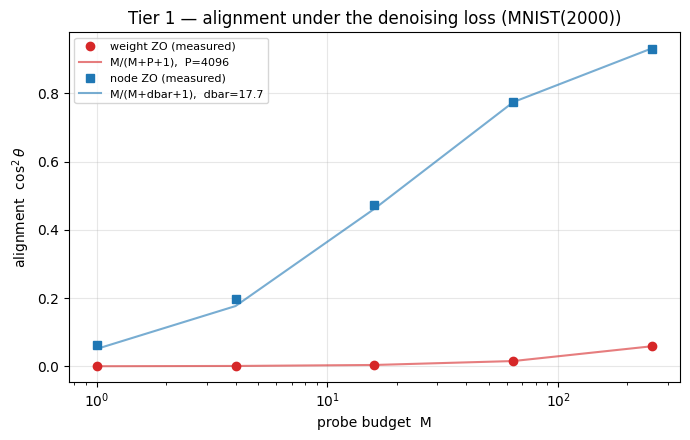

In [6]:
Mg = np.array(Ms)
plt.figure(figsize=(7,4.5))
plt.plot(Mg, [cw[M] for M in Ms], "o", color="C3", label="weight ZO (measured)")
plt.plot(Mg, Mg/(Mg+P+1), "-", color="C3", alpha=.6, label=f"M/(M+P+1),  P={P}")
plt.plot(Mg, [cn[M] for M in Ms], "s", color="C0", label="node ZO (measured)")
plt.plot(Mg, Mg/(Mg+dbar+1), "-", color="C0", alpha=.6, label=f"M/(M+dbar+1),  dbar={dbar:.1f}")
plt.xscale("log"); plt.xlabel("probe budget  M"); plt.ylabel(r"alignment  $\cos^2\theta$")
plt.title(f"Tier 1 — alignment under the denoising loss ({DATA})")
plt.legend(fontsize=8); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

**Pass:** dots on curves, node (blue) far above weight (red). With the seeded defaults you should see node $\cos^2\theta\approx0.95$ at $M=256$ where weight is $\approx0.11$, and $\bar d$ one to two orders of magnitude below $P$. If not: shrink `mu` (finite-difference bias), or check $E_A,E_B$ (wrong $\beta$).

## Experiment 2 — rank sweep and the Eckart–Young knee

We inject a **controlled rank-$\rho$ task shift** into the data, freeze the pretrained base, and train a **backprop-LoRA control** at each rank. Two things to watch:

- **final loss vs rank** should drop steeply then flatten at the task's intrinsic rank $\rho$ — the *operational* knee.
- the Frobenius **energy** $f(r)=\sum_{i\le r}\sigma_i^2/\sum_i\sigma_i^2$ of $\Delta W^\ast=B^\ast A^\ast$ is a *diagnostic*; when it disagrees with the loss knee, that gap measures Hessian anisotropy (the loss curve is the honest one — see the note below).

In [7]:
Ds = torch.randn(d, rho, device=dev) / rho**0.5
Xs = X0 + 1.2 * (torch.randn(len(X0), rho, device=dev) @ Ds.t()); Xs = Xs / Xs.std()

def train_lora(r, steps):
    A = rp(r, H).requires_grad_(); B = torch.zeros(H, r, device=dev, requires_grad=True)
    o = torch.optim.Adam([A, B], lr=3e-2)
    for s in range(steps):
        xt, tn, eps = make_batch(Xs, 128)
        o.zero_grad(); L = dloss(xt, tn, eps, A, B); L.backward(); o.step()
    with torch.no_grad():
        xt, tn, eps = make_batch(Xs, 512); Lf = dloss(xt, tn, eps, A, B).item()
    return Lf, (B @ A).detach()

losses = {}; dW_top = None
for rr in ranks:
    losses[rr], dW = train_lora(rr, lora_steps)
    if rr == max(ranks): dW_top = dW
sig = torch.linalg.svdvals(dW_top)
f = (torch.cumsum(sig**2, 0) / (sig**2).sum()).cpu().numpy()
with torch.no_grad():
    xt, tn, eps = make_batch(Xs, 512)
    L0 = dloss(xt, tn, eps, torch.zeros(1,H,device=dev), torch.zeros(H,1,device=dev)).item()

print(f"frozen base on shifted task (r=0): loss = {L0:.3f}   (injected task-shift rank rho={rho})")
print(f"{'r':>3} {'final loss':>11} {'f(r) energy':>12}")
print(f"{0:>3} {L0:>11.3f} {'-':>12}")
for rr in ranks:
    print(f"{rr:>3} {losses[rr]:>11.3f} {f[rr-1]:>12.3f}")

frozen base on shifted task (r=0): loss = 446.930   (injected task-shift rank rho=4)
  r  final loss  f(r) energy
  0     446.930            -
  1     423.427        0.980
  2     423.182        0.995
  4     421.753        0.997
  8     420.660        0.999
 16     421.249        1.000
 32     424.215        1.000


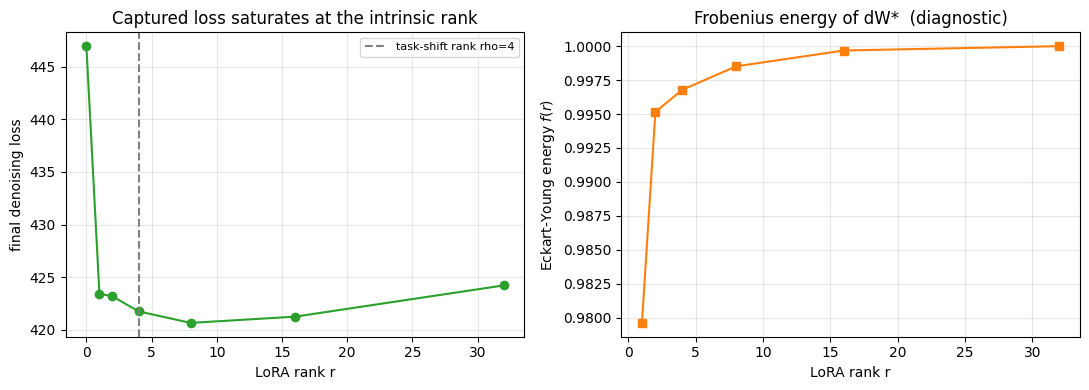

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11,4))
ax[0].plot([0]+ranks, [L0]+[losses[r] for r in ranks], "o-", color="C2")
ax[0].axvline(rho, ls="--", color="gray", label=f"task-shift rank rho={rho}")
ax[0].set_xlabel("LoRA rank r"); ax[0].set_ylabel("final denoising loss")
ax[0].set_title("Captured loss saturates at the intrinsic rank"); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)
ax[1].plot(ranks, [f[r-1] for r in ranks], "s-", color="C1")
ax[1].set_xlabel("LoRA rank r"); ax[1].set_ylabel(r"Eckart-Young energy $f(r)$")
ax[1].set_title("Frobenius energy of dW*  (diagnostic)"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

**How to read it.**

- **Loss knee at $r\approx\rho$** is the operational result: past the task's intrinsic rank, more parameters barely help — the Eckart–Young / intrinsic-dimension prediction. The efficient rank $r^\ast$ is here.
- **Energy vs loss divergence** is expected and honest: the Frobenius energy $f(r)$ can rise more slowly than the loss saturates, because loss reduction is Hessian-weighted, not Frobenius-weighted (Assumption of isotropy). When they disagree, **trust the loss curve** and, for the paper, use the $\mathcal H$-weighted spectrum (the open proof-obligation).

**Falsification.**
- If loss keeps dropping past $\rho$ with no knee, the base was undertrained (residual is high-rank) — pretrain the base longer.
- If node ZO does not beat weight ZO here as in Experiment 1, the estimator wiring is wrong.
- The knee must be the **same** whether you train the control with backprop or run node/weight ZO; a moving knee means the estimator is contaminating the approximation floor.

## What Tier 1 establishes — and what's next

**Established (small scale, T4-or-CPU):** the alignment laws hold under the real diffusion denoising loss (node $\bar d\ll P$), and captured loss saturates at the task's intrinsic rank as Eckart–Young predicts — with the honest caveat that the *loss* knee, not the raw energy knee, is the operative one.

**Next:**
- **Tier 2 (A100):** scale $d,H$, more data, more ranks; run the ZO estimators (not just the backprop control) at each rank to confirm $M^\ast(r)$ grows linearly with the predicted slopes.
- **Tier 3 (TPU v5e/v6e):** the open-weight diffusion backbone; identify which layer's residual channel is local, and post-train that segment.
